---
date: "2026-04-18"
date-modified: last-modified
format:
  html:
    toc: true
---


# The Birthday Problem

## 1\. Problem Statement and Assumptions

Suppose a group of $k$ individuals is gathered in a room. What is the probability that at least two individuals share the exact same birthday?

To solve this mathematically, we must make a few standard simplifying assumptions:

  * **365 Days:** We ignore leap years, assuming every year has exactly $365$ days.
  * **Uniform Distribution:** Birthdays are equally likely to fall on any day of the year (no seasonal birth clustering).
  * **Independence:** The birthday of one person is completely independent of the birthday of any other person (e.g., there are no twins in the room).

-----

## 2\. Mathematical Solution (The Complement Method)

If we try to calculate the probability of "at least one shared birthday" directly, the math is incredibly messy because we have to account for exactly two people sharing, or three people, or two pairs of two people, etc.

Instead, it is much simpler to use the complement rule: calculate the probability that **nobody** shares a birthday, and subtract that from $1$.

$$P(\text{Match}) = 1 - P(\text{No Match})$$

**Step 1: Total Possible Outcomes**
By the fundamental counting principle, each of the $k$ people can have their birthday on any of the $365$ days. Because multiple people *can* have the same birthday, this is a case of [sampling with replacement](sampling-with-replacement.ipynb).
$$\text{Total Outcomes} = \underbrace{365 \times 365 \times \dots \times 365}_{k \text{ times}} = 365^k$$

**Step 2: Favorable Outcomes (No Matches)**
For everyone to have a unique birthday, the first person can be born on any of the $365$ days. The second person only has $364$ days available. The third has $363$, and so on. This is a case of [sampling without replacement](sampling-without-replacement.ipynb).
$$\text{Unique Outcomes} = 365 \times 364 \times \dots \times (365 - k + 1)$$

*Note: This is equivalent to the permutation formula $P(365, k) = \frac{365!}{(365-k)!}$.*

**Step 3: Final Probability**
Using the naive definition of probability:
$$P(\text{Match}) = 1 - \frac{365 \times 364 \times \dots \times (365 - k + 1)}{365^k}$$

-----

## 3\. The "Paradox" and Intuition

This problem is often called the **Birthday Paradox** because the human brain vastly underestimates how quickly the probability grows.

  * At **$k = 23$** people, the probability crosses the $50\%$ threshold ($50.7\%$).
  * At **$k = 70$** people, the probability is over $99.9\%$.

**Why is it so low?**
When asked this question, people typically compare $k$ directly to $365$ (e.g., "23 is a tiny fraction of 365"). They are subconsciously answering the question: *"What is the probability that someone shares MY birthday?"* However, the problem asks if *any* two people share a birthday. We are not checking $k$ individuals; we are checking **pairs** of individuals.

The number of possible pairs in a room of $k$ people is calculated using the [binomial-coefficient](binomial-coefficient.ipynb):
$$\binom{k}{2} = \frac{k(k-1)}{2}$$

In a room of $23$ people, there are $\binom{23}{2} = 253$ unique pairs. With $253$ chances to find a match among $365$ days, a $>50\%$ probability suddenly makes intuitive sense.

-----

## 4\. Exponential Approximation

For larger values of $k$, calculating large factorials and powers is computationally expensive. We can approximate the probability using the Taylor series expansion $e^{-x} \approx 1 - x$ (for small $x$).

The probability of *no* match can be rewritten as:
$$P(\text{No Match}) = 1 \times \left(1 - \frac{1}{365}\right) \times \left(1 - \frac{2}{365}\right) \times \dots \times \left(1 - \frac{k-1}{365}\right)$$

Approximating each term $(1 - \frac{i}{365})$ as $e^{-i/365}$:
$$P(\text{No Match}) \approx e^{-1/365} \cdot e^{-2/365} \dots e^{-(k-1)/365} = \exp\left(-\sum_{i=1}^{k-1} \frac{i}{365}\right)$$

Using the sum of an arithmetic progression $\sum i = \frac{k(k-1)}{2}$:
$$P(\text{No Match}) \approx e^{\frac{-k(k-1)}{2 \times 365}}$$

Thus, the probability of a match is closely approximated by:
$$P(\text{Match}) \approx 1 - e^{\frac{-k(k-1)}{730}}$$

-----

## 5\. Python Visualization and Simulation

The following Python code calculates the exact theoretical probability for room sizes from 1 to 80 and visualizes the famous non-linear curve, highlighting the $50\%$ threshold at $k=23$.

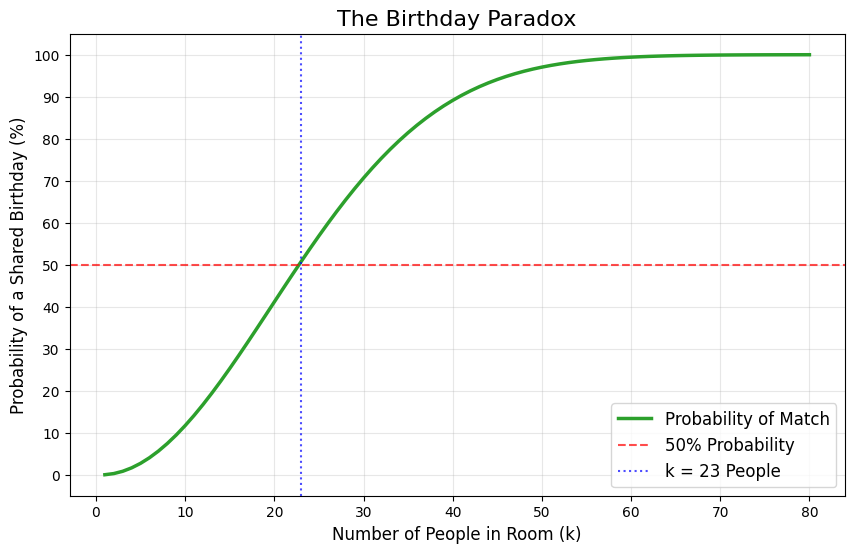

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exact_birthday_probability(k):
    """Calculates the exact probability of at least one shared birthday."""
    if k > 365:
        return 1.0
    
    prob_no_match = 1.0
    for i in range(k):
        prob_no_match *= (365 - i) / 365
        
    return 1.0 - prob_no_match

# Generate data for k from 1 to 80
k_values = np.arange(1, 81)
probabilities = [exact_birthday_probability(k) * 100 for k in k_values]

# Create the visualization
plt.figure(figsize=(10, 6))
plt.plot(k_values, probabilities, label='Probability of Match', color='#2ca02c', linewidth=2.5)

# Highlight the k=23 threshold
plt.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% Probability')
plt.axvline(x=23, color='blue', linestyle=':', alpha=0.7, label='k = 23 People')

# Formatting
plt.title('The Birthday Paradox', fontsize=16)
plt.xlabel('Number of People in Room (k)', fontsize=12)
plt.ylabel('Probability of a Shared Birthday (%)', fontsize=12)
plt.yticks(np.arange(0, 110, 10))
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=12)

# Display the plot
plt.show()